# Clustering
## Dataset Iris

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans



In [2]:
# 1. Carregamento dos dados
# Carregamos apenas as 'features'. No clustering, ignoramos os rótulos (labels).
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)



In [3]:
print("Primeiras linhas do dataset:")
print(df.head())



Primeiras linhas do dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


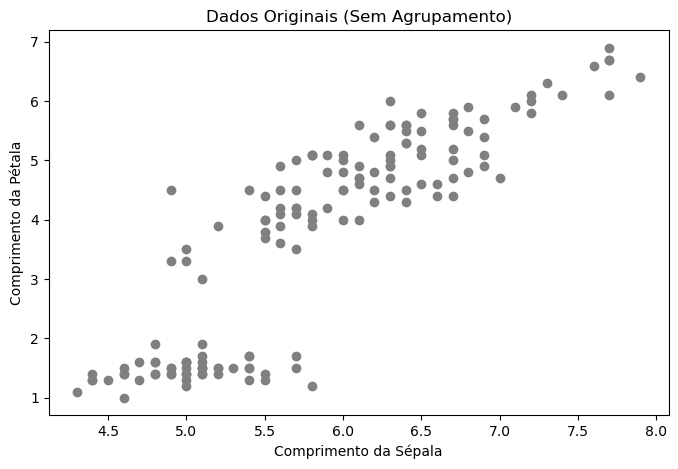

In [4]:
# 2. Visualização Inicial (Sem clusters)
plt.figure(figsize=(8, 5))
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'], c='gray')
plt.title("Dados Originais (Sem Agrupamento)")
plt.xlabel("Comprimento da Sépala")
plt.ylabel("Comprimento da Pétala")
plt.show()



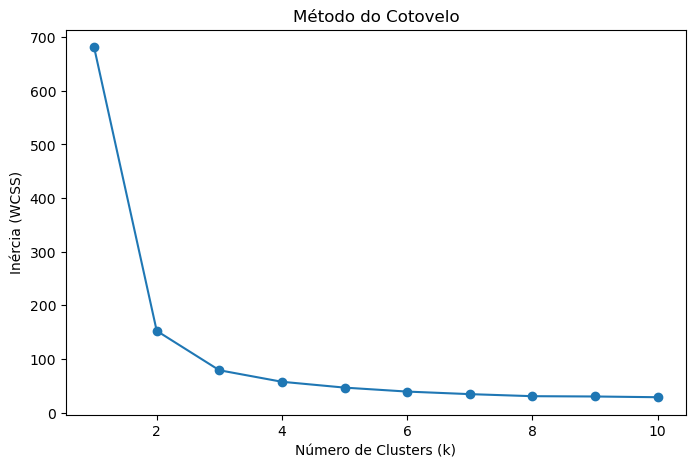

In [5]:
# 3. Método do Cotovelo (Elbow Method) para encontrar o 'k' ideal
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (WCSS)')
plt.show()

# Comentário: O "cotovelo" do gráfico indica que 3 clusters é o ponto ideal 
# onde a inércia deixa de cair drasticamente.



In [6]:
# 4. Treino do Modelo K-Means
k_ideal = 3
kmeans = KMeans(n_clusters=k_ideal, random_state=42)
df['cluster'] = kmeans.fit_predict(df)

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


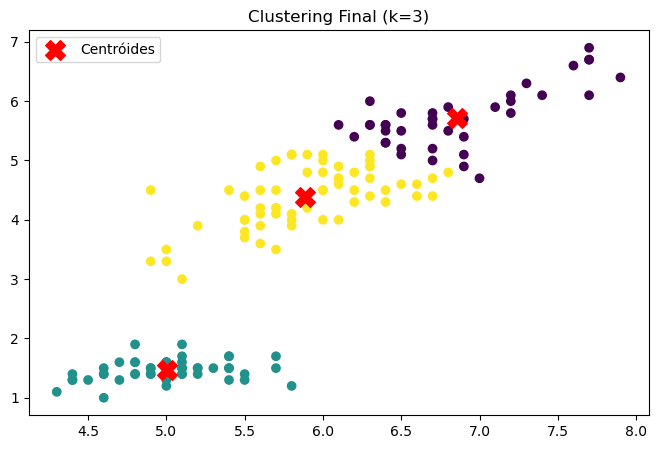

In [7]:
# 5. Visualização dos Resultados
plt.figure(figsize=(8, 5))
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'], c=df['cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='X', label='Centróides')
plt.title(f"Clustering Final (k={k_ideal})")
plt.legend()
plt.show()


In [8]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [9]:
df2=df.copy()

In [10]:
df2['target']=iris.target

In [11]:
df2

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster,target
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,2
146,6.3,2.5,5.0,1.9,2,2
147,6.5,3.0,5.2,2.0,0,2
148,6.2,3.4,5.4,2.3,0,2


In [12]:
df2.shape

(150, 6)

In [13]:
df2['cluster']=df2['cluster'].map({0:'dois',1:'zero',2:'um'})
df2['cluster']=df2['cluster'].map({'dois':2,'zero':0,'um':1})

In [14]:
err=df2[df2['cluster']!=df2['target']]
err

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster,target
50,7.0,3.2,4.7,1.4,2,1
52,6.9,3.1,4.9,1.5,2,1
77,6.7,3.0,5.0,1.7,2,1
101,5.8,2.7,5.1,1.9,1,2
106,4.9,2.5,4.5,1.7,1,2
113,5.7,2.5,5.0,2.0,1,2
114,5.8,2.8,5.1,2.4,1,2
119,6.0,2.2,5.0,1.5,1,2
121,5.6,2.8,4.9,2.0,1,2
123,6.3,2.7,4.9,1.8,1,2


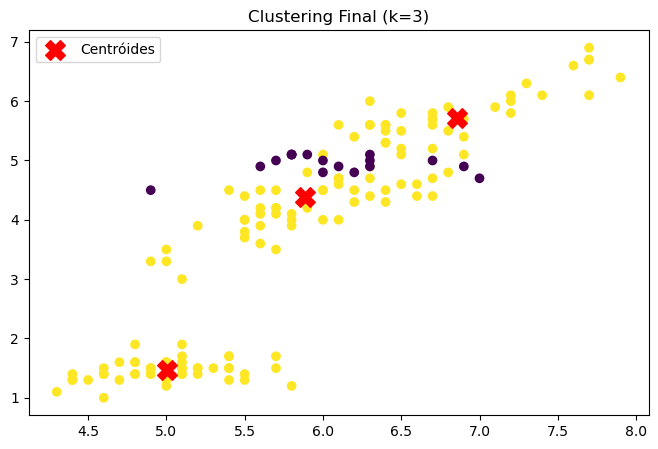

In [15]:
# 5. Visualização dos Resultados
plt.figure(figsize=(8, 5))
plt.scatter(df2['sepal length (cm)'], df2['petal length (cm)'], c=(df2['cluster']==df2['target']), cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='X', label='Centróides')
plt.title(f"Clustering Final (k={k_ideal})")
plt.legend()
plt.show()

In [16]:
df3 = df2.copy()
df3['correct'] = np.where(
    df3['cluster'] == df3['target'], # Condição
    df3['cluster'],                  # Valor se True
    df3['cluster'] + 10*df3['target']   # Valor se False
)
df3.correct.value_counts()

correct
0     50
1     47
2     36
21    14
12     3
Name: count, dtype: int64

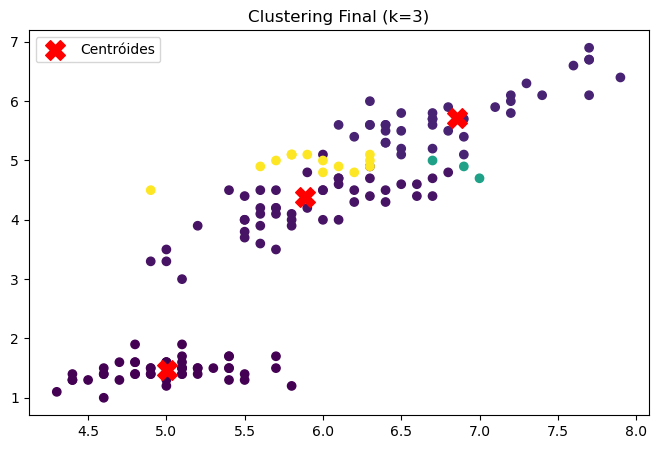

In [17]:
# 5. Visualização dos Resultados
plt.figure(figsize=(8, 5))
plt.scatter(df3['sepal length (cm)'], df3['petal length (cm)'], c=df3['correct'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='X', label='Centróides')
plt.title(f"Clustering Final (k={k_ideal})")
plt.legend()
plt.show()
